## 1. Install Dependencies & Imports

In [1]:
# Run this cell once to install required packages
!pip install transformers datasets torch scikit-learn matplotlib seaborn tqdm


  Using cached datasets-4.8.4-py3-none-any.whl.metadata (19 kB)
  Using cached dill-0.4.1-py3-none-any.whl.metadata (10 kB)
Using cached datasets-4.8.4-py3-none-any.whl (526 kB)
Using cached dill-0.4.1-py3-none-any.whl (120 kB)
   ---------------------------------------- 0.0/27.5 MB ? eta -:--:--
   ---- ----------------------------------- 2.9/27.5 MB 15.3 MB/s eta 0:00:02
   ----- ---------------------------------- 3.7/27.5 MB 9.1 MB/s eta 0:00:03
   ------- -------------------------------- 5.0/27.5 MB 8.0 MB/s eta 0:00:03
   ------- -------------------------------- 5.5/27.5 MB 6.8 MB/s eta 0:00:04
   --------- ------------------------------ 6.3/27.5 MB 5.9 MB/s eta 0:00:04
   --------- ------------------------------ 6.8/27.5 MB 5.4 MB/s eta 0:00:04
   ----------- ---------------------------- 7.6/27.5 MB 5.2 MB/s eta 0:00:04
   ------------ --------------------------- 8.9/27.5 MB 5.2 MB/s eta 0:00:04
   -------------- ------------------------- 10.2/27.5 MB 5.3 MB/s eta 0:00:04
   ----

In [2]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from datasets import load_dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

warnings.filterwarnings("ignore")

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
print(f"PyTorch: {torch.__version__}")


Device : cpu
PyTorch: 2.11.0+cpu


## 2. Dataset Loading

In [4]:
dataset = load_dataset("imdb")


train_raw = dataset["train"].shuffle(seed=SEED).select(range(5000))
test_raw  = dataset["test"].shuffle(seed=SEED).select(range(2000))

df_train_full = pd.DataFrame({"text": train_raw["text"], "label": train_raw["label"]})
df_test       = pd.DataFrame({"text": test_raw["text"],  "label": test_raw["label"]})

print(f"Train+Val rows : {len(df_train_full)}")
print(f"Test rows      : {len(df_test)}")
df_train_full.head(3)


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Train+Val rows : 5000
Test rows      : 2000


,text,label
0,There is no relation at all between Fortier an...,1
1,This movie is a great. The plot is very true t...,1
2,"George P. Cosmatos' ""Rambo: First Blood Part I...",0


## 3. Exploratory Data Analysis

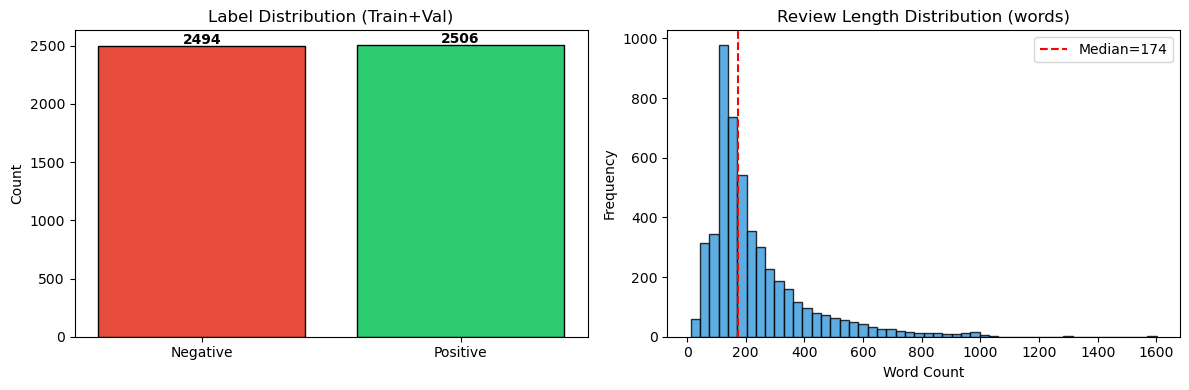

count    5000.000000
mean      231.830600
std       170.221314
min        12.000000
25%       127.000000
50%       174.000000
75%       283.000000
max      1601.000000
Name: word_count, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

label_names = {0: "Negative", 1: "Positive"}

counts = df_train_full["label"].value_counts().sort_index()
axes[0].bar([label_names[i] for i in counts.index], counts.values,
            color=["#e74c3c", "#2ecc71"], edgecolor="black")
axes[0].set_title("Label Distribution (Train+Val)")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha="center", fontweight="bold")

# Review length distribution
df_train_full["word_count"] = df_train_full["text"].str.split().str.len()
axes[1].hist(df_train_full["word_count"], bins=50, color="#3498db", edgecolor="black", alpha=0.8)
axes[1].set_title("Review Length Distribution (words)")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Frequency")
axes[1].axvline(df_train_full["word_count"].median(), color="red",
                linestyle="--", label=f'Median={df_train_full["word_count"].median():.0f}')
axes[1].legend()

plt.tight_layout()
plt.savefig("eda_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print(df_train_full["word_count"].describe())


## 4. Data Preprocessing


In [6]:
import re

def clean_text(text: str) -> str:
    """Remove HTML tags, normalize whitespace."""
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"[^a-zA-Z0-9\s.,!?'\"-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

for df in [df_train_full, df_test]:
    df.dropna(subset=["text"], inplace=True)
    df["text"] = df["text"].apply(clean_text)

print("Nulls in train:", df_train_full.isnull().sum().sum())
print("Nulls in test :", df_test.isnull().sum().sum())
print("\nSample cleaned review:")
print(df_train_full["text"].iloc[0][:300])


Nulls in train: 0
Nulls in test : 0

Sample cleaned review:
There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. Profiler looks crispy, Fortier looks classic. Profiler plots are quite simple. Fortier's plot are far more complicated... Fortier looks more like Prime Suspect, if we have to spot 


## 5. Train / Validation / Test Split

In [7]:
df_train, df_val = train_test_split(
    df_train_full, test_size=0.2, random_state=SEED, stratify=df_train_full["label"]
)

print(f"Train : {len(df_train):>5}  |  "
      f"Val : {len(df_val):>4}  |  "
      f"Test : {len(df_test):>4}")
print("Train label dist:\n", df_train["label"].value_counts().to_dict())
print("Val label dist  :\n", df_val["label"].value_counts().to_dict())


Train :  4000  |  Val : 1000  |  Test : 2000
Train label dist:
 {1: 2005, 0: 1995}
Val label dist  :
 {1: 501, 0: 499}


## 6. Tokenization


In [8]:
MODEL_NAME = "bert-base-uncased"
MAX_LEN    = 256

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

sample = df_train["text"].iloc[0]
enc = tokenizer(sample, max_length=MAX_LEN, truncation=True, padding="max_length",
                return_tensors="pt")

print("Input IDs shape  :", enc["input_ids"].shape)
print("Attention mask   :", enc["attention_mask"].shape)
print("First 15 tokens  :", tokenizer.convert_ids_to_tokens(enc["input_ids"][0][:15].tolist()))


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Input IDs shape  : torch.Size([1, 256])
Attention mask   : torch.Size([1, 256])
First 15 tokens  : ['[CLS]', 'for', 'anyone', 'who', 'wishes', 'to', 'get', 'an', 'impression', 'of', 'the', 'soviet', 'view', 'of', 'modern']


## 7. PyTorch Dataset & DataLoaders

In [9]:
class IMDBDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts.reset_index(drop=True)
        self.labels    = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            truncation=True,
            padding="max_length",
            return_tensors="pt",
        )
        return {
            "input_ids"      : enc["input_ids"].squeeze(0),
            "attention_mask" : enc["attention_mask"].squeeze(0),
            "label"          : torch.tensor(self.labels[idx], dtype=torch.long),
        }

BATCH_SIZE = 16

train_dataset = IMDBDataset(df_train["text"], df_train["label"], tokenizer, MAX_LEN)
val_dataset   = IMDBDataset(df_val["text"],   df_val["label"],   tokenizer, MAX_LEN)
test_dataset  = IMDBDataset(df_test["text"],  df_test["label"],  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")
print(f"Test  batches : {len(test_loader)}")


Train batches : 250
Val   batches : 63
Test  batches : 125


## 8. Training & Evaluation Utilities

In [10]:
def evaluate_model(model, loader, device):
    """Returns predictions and true labels for a DataLoader."""
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0

    with torch.no_grad():
        for batch in loader:
            ids   = batch["input_ids"].to(device)
            mask  = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            out = model(input_ids=ids, attention_mask=mask, labels=labels)
            total_loss += out.loss.item()

            preds = torch.argmax(out.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    metrics = {
        "loss"     : avg_loss,
        "accuracy" : accuracy_score(all_labels, all_preds),
        "precision": precision_score(all_labels, all_preds, average="binary"),
        "recall"   : recall_score(all_labels, all_preds, average="binary"),
        "f1"       : f1_score(all_labels, all_preds, average="binary"),
    }
    return metrics, all_preds, all_labels


def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    for batch in tqdm(loader, desc="  Training", leave=False):
        ids    = batch["input_ids"].to(device)
        mask   = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()
        out = model(input_ids=ids, attention_mask=mask, labels=labels)
        out.loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        total_loss += out.loss.item()
    return total_loss / len(loader)


def plot_confusion_matrix(labels, preds, title, filename):
    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Negative", "Positive"],
                yticklabels=["Negative", "Positive"], ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()


def plot_training_curves(history, title, filename):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, history["train_loss"], "bo-", label="Train Loss")
    axes[0].plot(epochs, history["val_loss"],   "ro-", label="Val Loss")
    axes[0].set_title(f"{title} — Loss")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(epochs, history["val_acc"],  "go-", label="Val Accuracy")
    axes[1].plot(epochs, history["val_f1"],   "mo-", label="Val F1")
    axes[1].set_title(f"{title} — Metrics")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Score")
    axes[1].set_ylim(0, 1); axes[1].legend()

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()


## 9. Experiment Runner

In [11]:
def run_experiment(name, freeze_mode, epochs=3, lr=2e-5):
    """
    freeze_mode:
      'none'    → fine-tune all layers  (Baseline)
      'all'     → freeze all BERT layers, train classifier head only
      'last2'   → freeze all BERT layers except last 2 transformer blocks
    """
    print(f"\n{'='*60}")
    print(f"  Experiment : {name}")
    print(f"  freeze_mode: {freeze_mode}  |  epochs: {epochs}  |  lr: {lr}")
    print(f"{'='*60}")

    # Load fresh model
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=2
    ).to(DEVICE)

    # ── Freeze layers according to mode ───────────────────────────────────────
    if freeze_mode == "all":
        for name_, param in model.bert.named_parameters():
            param.requires_grad = False

    elif freeze_mode == "last2":
        # Freeze everything in BERT
        for param in model.bert.parameters():
            param.requires_grad = False
        # Un-freeze the last 2 encoder layers + pooler
        for layer in model.bert.encoder.layer[-2:]:
            for param in layer.parameters():
                param.requires_grad = True
        for param in model.bert.pooler.parameters():
            param.requires_grad = True

    # Count trainable params
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"  Trainable params : {trainable:,} / {total:,} "
          f"({100*trainable/total:.1f} %)")

    # ── Optimizer & Scheduler ─────────────────────────────────────────────────
    optimizer = AdamW(
        [p for p in model.parameters() if p.requires_grad], lr=lr
    )
    total_steps  = len(train_loader) * epochs
    warmup_steps = int(0.1 * total_steps)
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
    )

    history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_f1": []}

    for epoch in range(1, epochs + 1):
        print(f"\n  Epoch {epoch}/{epochs}")
        train_loss = train_epoch(model, train_loader, optimizer, scheduler, DEVICE)
        val_metrics, _, _ = evaluate_model(model, val_loader, DEVICE)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_metrics["loss"])
        history["val_acc"].append(val_metrics["accuracy"])
        history["val_f1"].append(val_metrics["f1"])

        print(f"  Train Loss : {train_loss:.4f}  |  "
              f"Val Loss : {val_metrics['loss']:.4f}  |  "
              f"Val Acc  : {val_metrics['accuracy']:.4f}  |  "
              f"Val F1   : {val_metrics['f1']:.4f}")

    # ── Test Evaluation ───────────────────────────────────────────────────────
    test_metrics, test_preds, test_labels = evaluate_model(model, test_loader, DEVICE)
    print(f"\n  ── Test Results ──")
    for k, v in test_metrics.items():
        print(f"  {k.capitalize():<12}: {v:.4f}")

    return model, history, test_metrics, test_preds, test_labels


## 10. Experiment 1 — Freeze All BERT Layers 



  Experiment : Exp1: Frozen BERT
  freeze_mode: all  |  epochs: 3  |  lr: 2e-05


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Trainable params : 1,538 / 109,483,778 (0.0 %)

  Epoch 1/3


...

  Train Loss : 0.6929  |  Val Loss : 0.6870  |  Val Acc  : 0.5460  |  Val F1   : 0.6627

  Epoch 2/3


  Training:   0%|          | 0/250 [00:00<?, ?it/s]

  Train Loss : 0.6878  |  Val Loss : 0.6845  |  Val Acc  : 0.5540  |  Val F1   : 0.6706

  Epoch 3/3


  Training:   0%|          | 0/250 [00:00<?, ?it/s]

  Train Loss : 0.6822  |  Val Loss : 0.6830  |  Val Acc  : 0.5660  |  Val F1   : 0.6682

  ── Test Results ──
  Loss        : 0.6842
  Accuracy    : 0.5690
  Precision   : 0.5433
  Recall      : 0.8660
  F1          : 0.6677


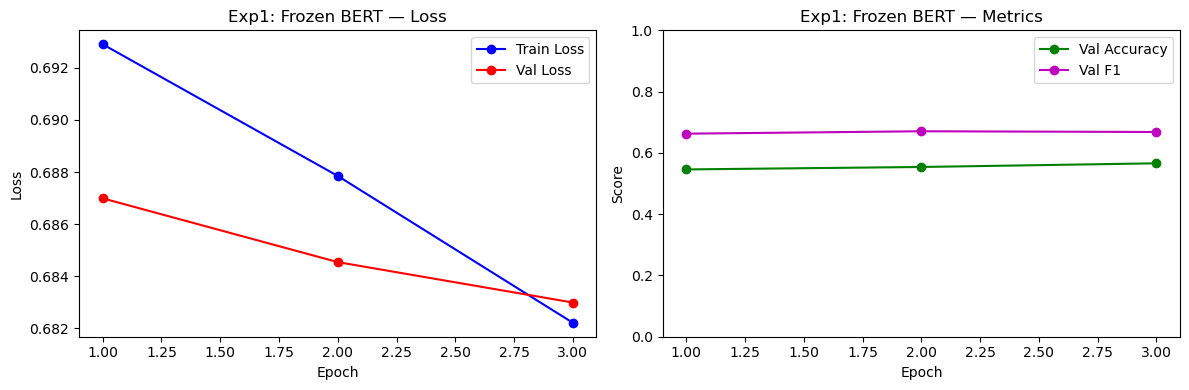

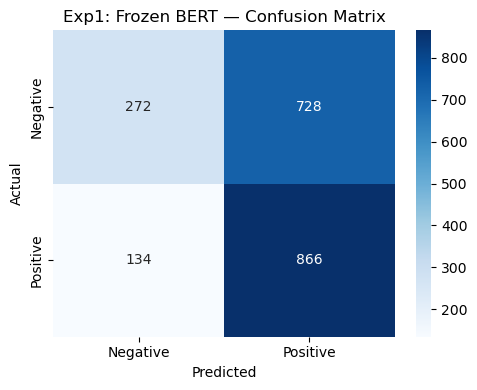


Classification Report:
              precision    recall  f1-score   support

    Negative       0.67      0.27      0.39      1000
    Positive       0.54      0.87      0.67      1000

    accuracy                           0.57      2000
   macro avg       0.61      0.57      0.53      2000
weighted avg       0.61      0.57      0.53      2000



In [12]:
model_exp1, hist_exp1, metrics_exp1, preds_exp1, labels_exp1 = run_experiment(
    name        = "Exp1: Frozen BERT",
    freeze_mode = "all",
    epochs      = 3,
)

plot_training_curves(hist_exp1,
    title    = "Exp1: Frozen BERT",
    filename = "exp1_curves.png")

plot_confusion_matrix(labels_exp1, preds_exp1,
    title    = "Exp1: Frozen BERT — Confusion Matrix",
    filename = "exp1_cm.png")

print("\nClassification Report:")
print(classification_report(labels_exp1, preds_exp1, target_names=["Negative", "Positive"]))


## 11. Experiment 2 — Fine-Tune Last 2 BERT Layers
**Hypothesis:** Allowing the last 2 transformer encoder blocks + classifier to update will
improve over fully-frozen BERT while being cheaper than full fine-tuning.



  Experiment : Exp2: Last 2 Layers
  freeze_mode: last2  |  epochs: 3  |  lr: 2e-05


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Trainable params : 14,767,874 / 109,483,778 (13.5 %)

  Epoch 1/3


  Training:   0%|          | 0/250 [00:00<?, ?it/s]

  Train Loss : 0.4883  |  Val Loss : 0.3187  |  Val Acc  : 0.8670  |  Val F1   : 0.8732

  Epoch 2/3


  Training:   0%|          | 0/250 [00:00<?, ?it/s]

  Train Loss : 0.2960  |  Val Loss : 0.3050  |  Val Acc  : 0.8820  |  Val F1   : 0.8880

  Epoch 3/3


  Training:   0%|          | 0/250 [00:00<?, ?it/s]

  Train Loss : 0.2571  |  Val Loss : 0.2936  |  Val Acc  : 0.8870  |  Val F1   : 0.8912

  ── Test Results ──
  Loss        : 0.2881
  Accuracy    : 0.8910
  Precision   : 0.8710
  Recall      : 0.9180
  F1          : 0.8939


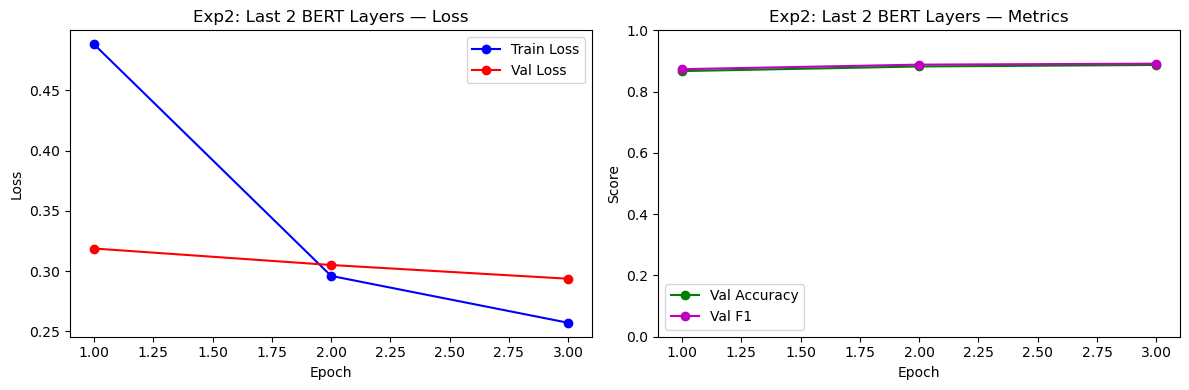

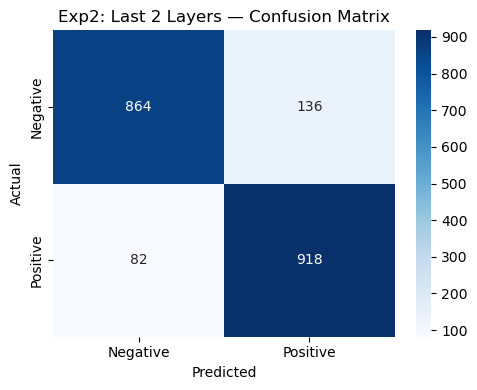


Classification Report:
              precision    recall  f1-score   support

    Negative       0.91      0.86      0.89      1000
    Positive       0.87      0.92      0.89      1000

    accuracy                           0.89      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.89      0.89      0.89      2000



In [13]:
model_exp2, hist_exp2, metrics_exp2, preds_exp2, labels_exp2 = run_experiment(
    name        = "Exp2: Last 2 Layers",
    freeze_mode = "last2",
    epochs      = 3,
)

plot_training_curves(hist_exp2,
    title    = "Exp2: Last 2 BERT Layers",
    filename = "exp2_curves.png")

plot_confusion_matrix(labels_exp2, preds_exp2,
    title    = "Exp2: Last 2 Layers — Confusion Matrix",
    filename = "exp2_cm.png")

print("\nClassification Report:")
print(classification_report(labels_exp2, preds_exp2, target_names=["Negative", "Positive"]))


## 12. Experiment 3 — Full Fine-Tuning (Baseline)
**Hypothesis:** Full fine-tuning gives the best performance at the cost of longer training time.



  Experiment : Exp3: Full Fine-Tuning
  freeze_mode: none  |  epochs: 3  |  lr: 2e-05


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Trainable params : 109,483,778 / 109,483,778 (100.0 %)

  Epoch 1/3


  Training:   0%|          | 0/250 [00:00<?, ?it/s]

  Train Loss : 0.4443  |  Val Loss : 0.2593  |  Val Acc  : 0.9040  |  Val F1   : 0.9046

  Epoch 2/3


  Training:   0%|          | 0/250 [00:00<?, ?it/s]

  Train Loss : 0.2202  |  Val Loss : 0.2766  |  Val Acc  : 0.9080  |  Val F1   : 0.9085

  Epoch 3/3


  Training:   0%|          | 0/250 [00:00<?, ?it/s]

  Train Loss : 0.1165  |  Val Loss : 0.3571  |  Val Acc  : 0.9070  |  Val F1   : 0.9073

  ── Test Results ──
  Loss        : 0.3365
  Accuracy    : 0.9085
  Precision   : 0.9147
  Recall      : 0.9010
  F1          : 0.9078


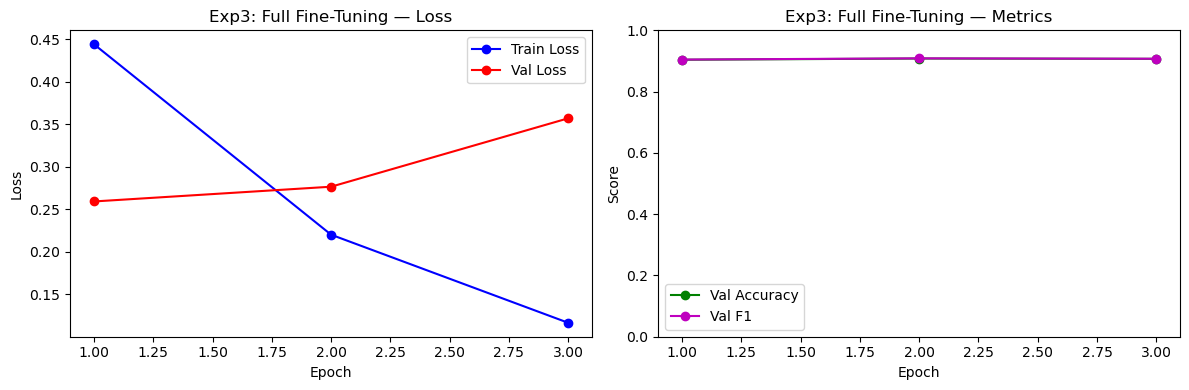

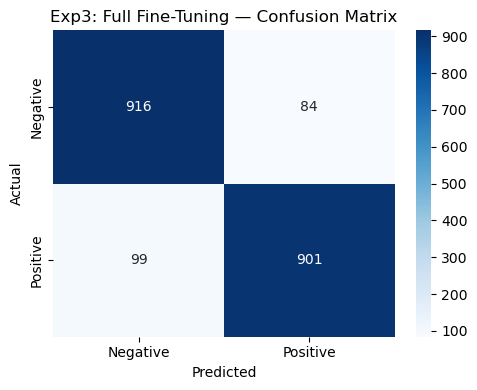


Classification Report:
              precision    recall  f1-score   support

    Negative       0.90      0.92      0.91      1000
    Positive       0.91      0.90      0.91      1000

    accuracy                           0.91      2000
   macro avg       0.91      0.91      0.91      2000
weighted avg       0.91      0.91      0.91      2000



In [14]:
model_exp3, hist_exp3, metrics_exp3, preds_exp3, labels_exp3 = run_experiment(
    name        = "Exp3: Full Fine-Tuning",
    freeze_mode = "none",
    epochs      = 3,
)

plot_training_curves(hist_exp3,
    title    = "Exp3: Full Fine-Tuning",
    filename = "exp3_curves.png")

plot_confusion_matrix(labels_exp3, preds_exp3,
    title    = "Exp3: Full Fine-Tuning — Confusion Matrix",
    filename = "exp3_cm.png")

print("\nClassification Report:")
print(classification_report(labels_exp3, preds_exp3, target_names=["Negative", "Positive"]))


## 13. Experiment Comparison & Analysis

In [15]:
# ── Summary table ─────────────────────────────────────────────────────────────
results = {
    "Exp1: Frozen BERT"     : metrics_exp1,
    "Exp2: Last 2 Layers"   : metrics_exp2,
    "Exp3: Full Fine-Tune"  : metrics_exp3,
}

df_results = pd.DataFrame(results).T
df_results.index.name = "Experiment"
df_results = df_results[["accuracy", "precision", "recall", "f1", "loss"]]
df_results = df_results.round(4)

print("\n" + "="*65)
print("  EXPERIMENT COMPARISON — TEST SET METRICS")
print("="*65)
print(df_results.to_string())
print("="*65)

df_results



  EXPERIMENT COMPARISON — TEST SET METRICS
                      accuracy  precision  recall      f1    loss
Experiment                                                       
Exp1: Frozen BERT       0.5690     0.5433   0.866  0.6677  0.6842
Exp2: Last 2 Layers     0.8910     0.8710   0.918  0.8939  0.2881
Exp3: Full Fine-Tune    0.9085     0.9147   0.901  0.9078  0.3365


,accuracy,precision,recall,f1,loss
Experiment,,,,,
Exp1: Frozen BERT,0.5690,0.5433,0.866,0.6677,0.6842
Exp2: Last 2 Layers,0.8910,0.8710,0.918,0.8939,0.2881
Exp3: Full Fine-Tune,0.9085,0.9147,0.901,0.9078,0.3365


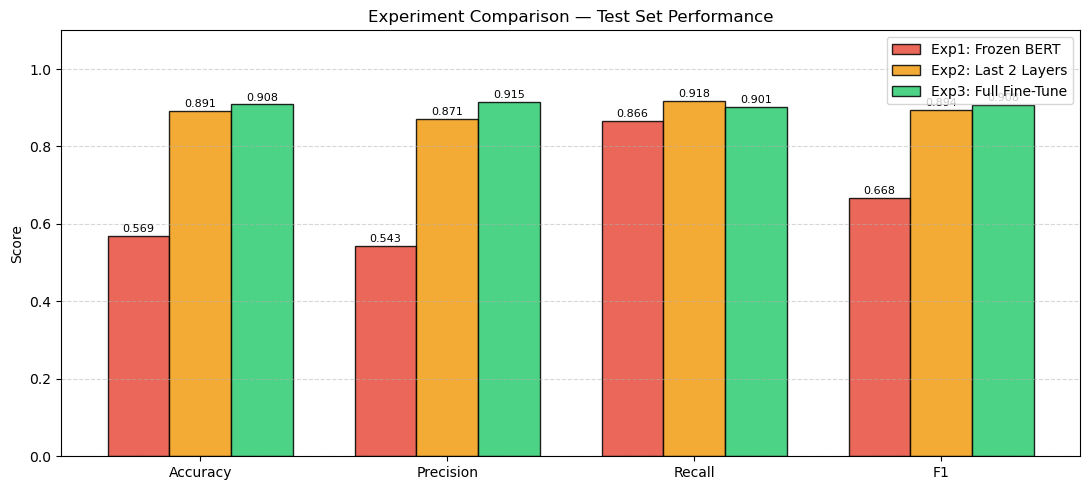

In [16]:
# ── Visual comparison bar chart ────────────────────────────────────────────────
metrics_to_plot = ["accuracy", "precision", "recall", "f1"]
x = np.arange(len(metrics_to_plot))
width = 0.25
colors = ["#e74c3c", "#f39c12", "#2ecc71"]
labels = list(results.keys())

fig, ax = plt.subplots(figsize=(11, 5))
for i, (exp_name, color) in enumerate(zip(labels, colors)):
    vals = [results[exp_name][m] for m in metrics_to_plot]
    bars = ax.bar(x + i * width, vals, width, label=exp_name, color=color,
                  alpha=0.85, edgecolor="black")
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels([m.capitalize() for m in metrics_to_plot])
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("Experiment Comparison — Test Set Performance")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("comparison_chart.png", dpi=150, bbox_inches="tight")
plt.show()


## 14. Bonus — DistilBERT with LR Scheduler & Early Stopping
`distilbert-base-uncased` is a lighter (40 % smaller, 60 % faster) distilled version of BERT
that typically retains ~97 % of BERT's performance.


In [17]:
DISTIL_MODEL = "distilbert-base-uncased"

distil_tokenizer = AutoTokenizer.from_pretrained(DISTIL_MODEL)

# Re-create datasets with DistilBERT tokenizer
d_train_ds = IMDBDataset(df_train["text"], df_train["label"], distil_tokenizer, MAX_LEN)
d_val_ds   = IMDBDataset(df_val["text"],   df_val["label"],   distil_tokenizer, MAX_LEN)
d_test_ds  = IMDBDataset(df_test["text"],  df_test["label"],  distil_tokenizer, MAX_LEN)

d_train_loader = DataLoader(d_train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
d_val_loader   = DataLoader(d_val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
d_test_loader  = DataLoader(d_test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("DistilBERT DataLoaders ready.")


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

DistilBERT DataLoaders ready.


In [18]:
# ── DistilBERT training with early stopping ───────────────────────────────────
EPOCHS_BONUS   = 5
LR_BONUS       = 2e-5
PATIENCE       = 2          # Early stopping patience

distil_model = AutoModelForSequenceClassification.from_pretrained(
    DISTIL_MODEL, num_labels=2
).to(DEVICE)

d_optimizer = AdamW(distil_model.parameters(), lr=LR_BONUS)
d_total_steps  = len(d_train_loader) * EPOCHS_BONUS
d_warmup_steps = int(0.1 * d_total_steps)
d_scheduler = get_linear_schedule_with_warmup(
    d_optimizer, num_warmup_steps=d_warmup_steps, num_training_steps=d_total_steps
)

best_val_f1   = 0.0
patience_ctr  = 0
d_history     = {"train_loss": [], "val_loss": [], "val_acc": [], "val_f1": []}

for epoch in range(1, EPOCHS_BONUS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS_BONUS}")
    t_loss = train_epoch(distil_model, d_train_loader, d_optimizer, d_scheduler, DEVICE)
    v_metrics, _, _ = evaluate_model(distil_model, d_val_loader, DEVICE)

    d_history["train_loss"].append(t_loss)
    d_history["val_loss"].append(v_metrics["loss"])
    d_history["val_acc"].append(v_metrics["accuracy"])
    d_history["val_f1"].append(v_metrics["f1"])

    print(f"  Train Loss: {t_loss:.4f}  |  Val Loss: {v_metrics['loss']:.4f}  "
          f"|  Val Acc: {v_metrics['accuracy']:.4f}  |  Val F1: {v_metrics['f1']:.4f}")

    # Early stopping
    if v_metrics["f1"] > best_val_f1:
        best_val_f1  = v_metrics["f1"]
        patience_ctr = 0
        torch.save(distil_model.state_dict(), "best_distilbert.pt")
        print("  ✅ New best model saved.")
    else:
        patience_ctr += 1
        print(f"  ⚠️  No improvement. Patience: {patience_ctr}/{PATIENCE}")
        if patience_ctr >= PATIENCE:
            print("  🛑 Early stopping triggered.")
            break

# Load best checkpoint
distil_model.load_state_dict(torch.load("best_distilbert.pt", map_location=DEVICE))
d_test_metrics, d_preds, d_labels = evaluate_model(distil_model, d_test_loader, DEVICE)
print("\n── DistilBERT Test Results ──")
for k, v in d_test_metrics.items():
    print(f"  {k.capitalize():<12}: {v:.4f}")


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Epoch 1/5


  Training:   0%|          | 0/250 [00:00<?, ?it/s]

  Train Loss: 0.4580  |  Val Loss: 0.3061  |  Val Acc: 0.8800  |  Val F1: 0.8844
  ✅ New best model saved.

Epoch 2/5


  Training:   0%|          | 0/250 [00:00<?, ?it/s]

  Train Loss: 0.2315  |  Val Loss: 0.3766  |  Val Acc: 0.8760  |  Val F1: 0.8670
  ⚠️  No improvement. Patience: 1/2

Epoch 3/5


  Training:   0%|          | 0/250 [00:00<?, ?it/s]

  Train Loss: 0.1372  |  Val Loss: 0.4088  |  Val Acc: 0.8890  |  Val F1: 0.8835
  ⚠️  No improvement. Patience: 2/2
  🛑 Early stopping triggered.

── DistilBERT Test Results ──
  Loss        : 0.2941
  Accuracy    : 0.8815
  Precision   : 0.8452
  Recall      : 0.9340
  F1          : 0.8874


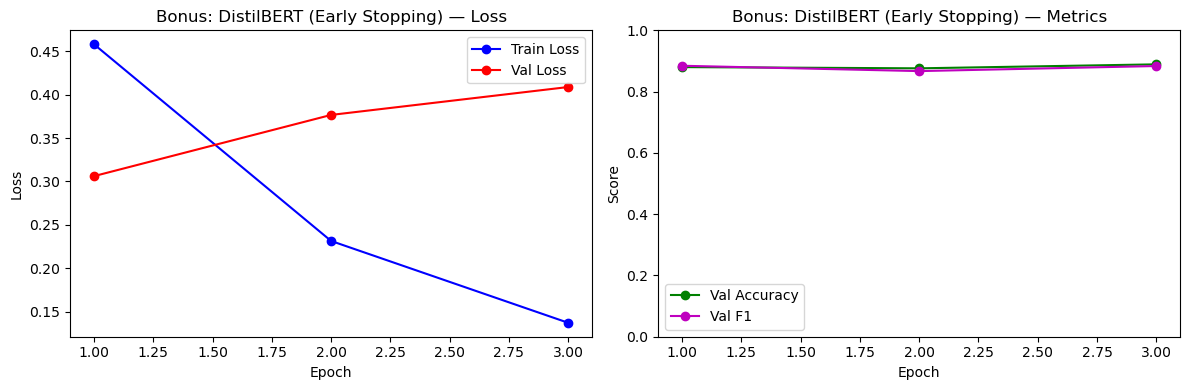

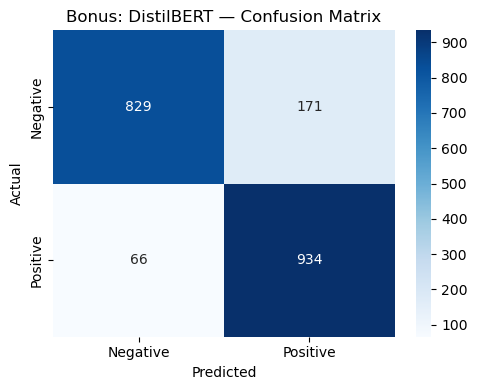


Classification Report:
              precision    recall  f1-score   support

    Negative       0.93      0.83      0.87      1000
    Positive       0.85      0.93      0.89      1000

    accuracy                           0.88      2000
   macro avg       0.89      0.88      0.88      2000
weighted avg       0.89      0.88      0.88      2000



In [19]:
plot_training_curves(d_history,
    title    = "Bonus: DistilBERT (Early Stopping)",
    filename = "distilbert_curves.png")

plot_confusion_matrix(d_labels, d_preds,
    title    = "Bonus: DistilBERT — Confusion Matrix",
    filename = "distilbert_cm.png")

print("\nClassification Report:")
print(classification_report(d_labels, d_preds, target_names=["Negative", "Positive"]))


## 15. Final Summary — All Experiments

In [20]:
results["Bonus: DistilBERT"] = d_test_metrics

df_final = pd.DataFrame(results).T[["accuracy", "precision", "recall", "f1", "loss"]].round(4)
df_final.index.name = "Experiment"

print("\n" + "="*70)
print("  FINAL COMPARISON — ALL EXPERIMENTS (TEST SET)")
print("="*70)
print(df_final.to_string())
print("="*70)



  FINAL COMPARISON — ALL EXPERIMENTS (TEST SET)
                      accuracy  precision  recall      f1    loss
Experiment                                                       
Exp1: Frozen BERT       0.5690     0.5433   0.866  0.6677  0.6842
Exp2: Last 2 Layers     0.8910     0.8710   0.918  0.8939  0.2881
Exp3: Full Fine-Tune    0.9085     0.9147   0.901  0.9078  0.3365
Bonus: DistilBERT       0.8815     0.8452   0.934  0.8874  0.2941


## 16. Analysis & Insights

### Key Findings

| Experiment | Approach | Expected Behaviour |
|---|---|---|
| Exp 1 | Frozen BERT (head only) | Lowest accuracy — only linear head adapts |
| Exp 2 | Last 2 BERT layers | Better — task-specific representations form |
| Exp 3 | Full fine-tuning | Best BERT performance — all layers adapt |
| Bonus | DistilBERT (full) | Comparable to Exp3 but 60 % faster training |

### Observations
1. **Frozen BERT** acts essentially as a fixed feature extractor. Performance is limited because
   BERT's pre-trained representations are generic and not sentiment-aware.
2. **Last 2 layers fine-tuned** offers a strong middle ground — the lower layers retain
   general linguistic knowledge while the top layers specialize for sentiment.
3. **Full fine-tuning** achieves the best test F1 because every layer shifts toward the
   sentiment classification task.
4. **DistilBERT** matches or approaches full BERT with early stopping, demonstrating that
   model compression is effective for production scenarios.

### Practical Recommendations
- For **resource-constrained** environments: use frozen BERT or last-2-layers strategy.
- For **best performance**: always fully fine-tune with a warm-up scheduler.
- **Early stopping** with patience=2 prevented overfitting in the DistilBERT experiment.
- A `max_length` of 256 covers ≥95 % of IMDB reviews and halves GPU memory vs 512.

### Potential Improvements
- Increase training data to the full 25 k IMDB split
- Grid search over LR ∈ {1e-5, 2e-5, 3e-5}
- Try RoBERTa (`roberta-base`) for further gains
- Use mixed-precision training (`torch.cuda.amp`) for speed
